In [51]:
#CLUSTERS
#K mean clusters

import numpy as np
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
Univ=pd.read_csv("D:\\csv files\\Universities.csv")
Univ.head()

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CMU,1260,62,59,9,25026,72
2,CalTech,1415,100,25,6,63575,81
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90


In [2]:
Univ.value_counts()

Univ          SAT   Top10  Accept  SFRatio  Expenses  GradRate
Brown         1310  89     22      13       22704     94          1
PennState     1081  38     54      18       10185     80          1
UWisconsin    1085  40     69      15       11857     71          1
UVA           1225  77     44      14       13349     92          1
UPenn         1285  80     36      11       27553     90          1
UMichigan     1180  65     68      16       15470     85          1
UChicago      1290  75     50      13       38380     87          1
UCBerkeley    1240  95     40      17       15140     78          1
TexasA&M      1075  49     67      25       8704      67          1
Stanford      1360  90     20      12       36450     93          1
Purdue        1005  28     90      19       9066      69          1
Princeton     1375  91     14      8        30220     95          1
NotreDame     1255  81     42      13       15122     94          1
CMU           1260  62     59      9        25026    

In [53]:
#Normalisation
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_Univ_df=scaler.fit_transform(Univ.iloc[: ,1:])
scaled_Univ_df

array([[ 0.41028362,  0.6575195 , -0.88986682,  0.07026045, -0.33141256,
         0.82030265],
       [-0.06065717, -0.76045386,  1.02438157, -0.93346022, -0.16712136,
        -1.65863393],
       [ 1.39925928,  1.23521235, -0.73465749, -1.68625071,  2.56038138,
        -0.64452351],
       [ 0.41028362, -0.02520842, -0.78639393, -0.18066972,  0.29164871,
         0.14422904],
       [ 0.12771914,  0.34241431, -0.32076595,  0.07026045, -0.39084607,
         0.36958691],
       [ 0.69284809,  0.6575195 , -0.83813038, -0.68253005,  0.33778044,
         0.93298158],
       [ 0.4573777 ,  0.71003703, -0.47597528, -0.18066972,  0.29695528,
         0.93298158],
       [-0.10775125, -0.13024348, -0.78639393, -0.18066972, -0.51381683,
         0.59494478],
       [ 1.25797704,  0.76255456, -1.30375836, -0.43159988,  0.85874344,
         1.15833946],
       [ 0.36318954, -0.07772595,  0.24833493, -1.43532055,  2.21481798,
         0.0315501 ],
       [ 1.06960072,  0.92010716, -0.47597528, -0.

In [14]:
range(1,4)

range(1, 4)

In [16]:
for i in range(1,4):
    print(i)

1
2
3


In [49]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [55]:
import warnings
warnings.filterwarnings('ignore')
wcss = []

kmeans=KMeans(n_clusters=4, random_state=0)

kmeans.fit(scaled_Univ_df)

wcss.append(kmeans.inertia_)

In [56]:
wcss

[34.79612750585774]

In [59]:
wcss=[]
for i in range(1,11):
  
    kmeans=KMeans(n_clusters=i, random_state=0)
   
    kmeans.fit(scaled_Univ_df)
   
    wcss.append(kmeans.inertia_)
   
    if i > 2:
        
        break
    wcss

In [60]:
wcss

[149.99999999999997, 64.1452839501027, 49.69054164653248]

In [58]:
kmeans.inertia_

49.69054164653248

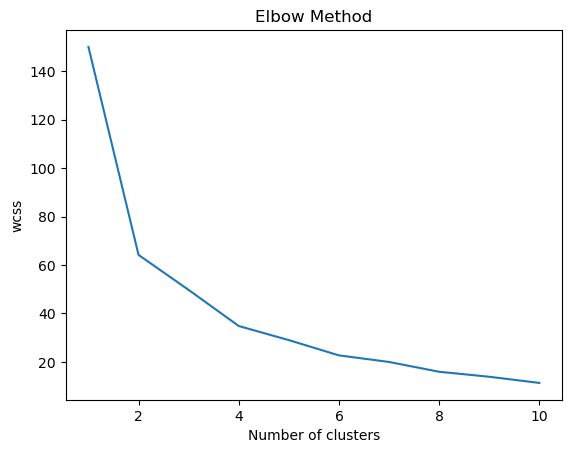

In [62]:
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=0)
    kmeans.fit(scaled_Univ_df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.show()

In [80]:
#build cluster algorithm
from sklearn.cluster import KMeans
clusters_new=KMeans(4,random_state=42)
clusters_new.fit(scaled_Univ_df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [70]:
cluster_new.labels_

array([2, 1, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 2, 3, 2, 2, 1, 2,
       2, 1, 2], dtype=int32)

In [77]:
Univ['clusterid_new']=clusters_new.labels_

In [82]:
clusters_new.cluster_centers_

array([[ 0.88122441,  0.5787432 , -0.24316128, -1.56078563,  2.38759968,
        -0.3064867 ],
       [-1.35856999, -1.56922385,  1.49000956,  0.67249284, -0.92455897,
        -1.27552555],
       [ 0.4019729 ,  0.47834204, -0.4942352 , -0.19543032,  0.06879803,
         0.5419194 ],
       [-1.8031381 , -1.44318177,  1.43827311,  3.08142243, -1.32197103,
        -2.22202861]])

In [88]:
Univ.groupby('clusterid_new').mean(numeric_only=True).reset_index()

,clusterid_new,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,0,1360.000000,87.500000,34.500000,6.500000,61133.000000,84.000000
1,1,1122.200000,46.600000,68.000000,15.400000,14320.800000,75.400000
2,2,1309.117647,85.588235,29.647059,11.941176,28360.352941,91.529412
3,3,1075.000000,49.000000,67.000000,25.000000,8704.000000,67.000000


In [89]:
Univ[Univ['clusterid_new']==3]


,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,clusterid_new
17,TexasA&M,1075,49,67,25,8704,67,3


In [90]:
Univ[Univ['clusterid_new']==0]

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,clusterid_new
2,CalTech,1415,100,25,6,63575,81,0
9,JohnsHopkins,1305,75,44,7,58691,87,0


In [91]:
Univ[Univ['clusterid_new']==2]

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate,clusterid_new
0,Brown,1310,89,22,13,22704,94,2
3,Columbia,1310,76,24,12,31510,88,2
4,Cornell,1280,83,33,13,21864,90,2
5,Dartmouth,1340,89,23,10,32162,95,2
6,Duke,1315,90,30,12,31585,95,2
7,Georgetown,1255,74,24,12,20126,92,2
8,Harvard,1400,91,14,11,39525,97,2
10,MIT,1380,94,30,10,34870,91,2
11,Northwestern,1260,85,39,11,28052,89,2
12,NotreDame,1255,81,42,13,15122,94,2


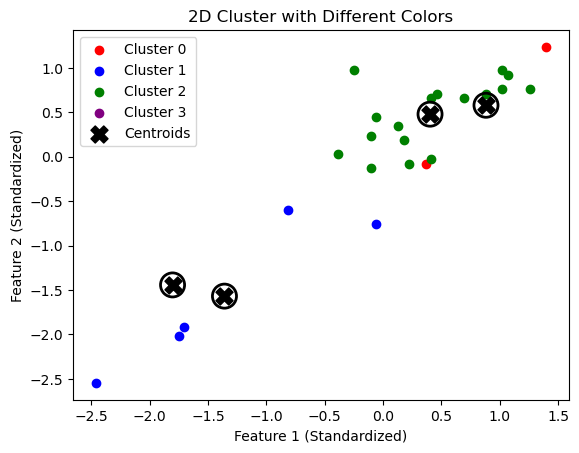

In [105]:
import matplotlib.pyplot as plt
import numpy as np

colors = ('red', 'blue', 'green', 'purple')

for i in range(4):

    plt.scatter(
        scaled_univ_df[clusters_new.labels_ == i, 0],
        scaled_univ_df[clusters_new.labels_ == i, 1],
        c=colors[i],
        label=f'Cluster {i}'
    )

# Cluster centers
plt.scatter(
    clusters_new.cluster_centers_[:, 0],
    clusters_new.cluster_centers_[:, 1],
    s=300,
    facecolors='none',
    edgecolors='black',
    linewidths=2
)

# Centroid X mark
plt.scatter(
    clusters_new.cluster_centers_[:, 0],
    clusters_new.cluster_centers_[:, 1],
    c='black',
    marker='X',
    s=150,
    label='Centroids'
)

plt.title('2D Cluster with Different Colors')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()

plt.show()      

In [106]:
#DBScan
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("D:\\csv files\\Wholesale_customers_data.csv")

In [107]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [109]:
array=df.values

In [112]:
stscaler=StandardScaler().fit(array)
x=stscaler.transform(array)
x

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]], shape=(440, 8))

In [113]:
dbscan=DBSCAN(eps=3,min_samples=7)
dbscan.fit(x)

,eps,3
,min_samples,7
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [114]:
dbscan.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [116]:
cl=pd.DataFrame(dbscan.labels_,columns=['cluster'])
cl

,cluster
0,0
1,0
2,0
3,0
4,0
...,...
435,0
436,0
437,0
438,0


In [118]:
clustered=pd.concat([df,cl],axis=1)

In [122]:
clustered[clustered['cluster']==-1]

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
23,2,3,26373,36423,22019,5154,4337,16523,-1
47,2,3,44466,54259,55571,7782,24171,6465,-1
61,2,3,35942,38369,59598,3254,26701,2017,-1
71,1,3,18291,1266,21042,5373,4173,14472,-1
85,2,3,16117,46197,92780,1026,40827,2944,-1
86,2,3,22925,73498,32114,987,20070,903,-1
87,1,3,43265,5025,8117,6312,1579,14351,-1
93,1,3,11314,3090,2062,35009,71,2698,-1
181,1,3,112151,29627,18148,16745,4948,8550,-1
183,1,3,36847,43950,20170,36534,239,47943,-1


In [124]:
clustered.mean()

Channel                 1.322727
Region                  2.543182
Fresh               12000.297727
Milk                 5796.265909
Grocery              7951.277273
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicassen           1524.870455
cluster                -0.027273
dtype: float64

In [125]:
from sklearn.metrics import silhouette_score
print("silhouette_score:",silhouette_score(x,dbscan.labels_))
      

silhouette_score: 0.6866475343140435


In [127]:
##RECOMENDATION SYSTEM (NEW CONCEPT)
import pandas as pd
import numpy as np
df=pd.read_csv("D:\\csv files\\Movie.csv")

In [129]:
df.shape

(8992, 3)

In [130]:
df.head()

,userId,movie,rating
0,3,Toy Story (1995),4.0
1,6,Toy Story (1995),5.0
2,8,Toy Story (1995),4.0
3,10,Toy Story (1995),4.0
4,11,Toy Story (1995),4.5


In [132]:
df.sort_values('userId')

,userId,movie,rating
2569,1,Jumanji (1995),3.5
3724,2,Grumpier Old Men (1995),4.0
0,3,Toy Story (1995),4.0
5204,4,Heat (1995),3.0
7444,4,GoldenEye (1995),4.0
...,...,...,...
6463,7117,Heat (1995),5.0
2567,7119,Toy Story (1995),5.0
2568,7120,Toy Story (1995),4.5
3723,7120,Jumanji (1995),4.0


In [133]:
len(df)
len(df.userId.unique())

4081

In [145]:
df1=df['rating'].value_counts()
df1

rating
3.0    2736
4.0    2660
5.0    1394
3.5     679
2.0     542
4.5     374
2.5     277
1.0     212
1.5      61
0.5      57
Name: count, dtype: int64

<Axes: >

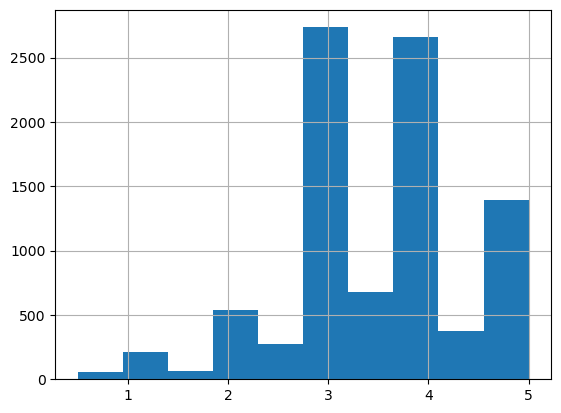

In [147]:
df['rating'].hist()

In [149]:
len(df.movie.unique())

10

In [150]:
df.movie.value_counts()

movie
Toy Story (1995)                      2569
GoldenEye (1995)                      1548
Heat (1995)                           1260
Jumanji (1995)                        1155
Sabrina (1995)                         700
Grumpier Old Men (1995)                685
Father of the Bride Part II (1995)     657
Sudden Death (1995)                    202
Waiting to Exhale (1995)               138
Tom and Huck (1995)                     78
Name: count, dtype: int64

In [152]:
#User item matrix
user_df=df.pivot(index='userId',columns='movie',values='rating')
user_df
user_df.iloc[0]
user_df.iloc[200]
list(user_df)
user_df.fillna(0, inplace=True)
user_df

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
userId,,,,,,,,,,
1,0.0,0.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
4,0.0,4.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
7115,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7116,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
7117,0.0,3.0,4.0,5.0,0.0,3.0,1.0,0.0,4.0,0.0


In [164]:
#compute user similarity
from sklearn.metrics import pairwise_distances
user_sim=1-pairwise_distances(user_df.values,metric='cosine')
user_sim.shape
np.fill_diagonal(user_sim,0)
user_sim_df=pd.DataFrame(user_sim)
user_sim_df.index=user_df.index
user_sim_df.columns=user_df.index
user_sim_df.iloc[0:7,0:7]

userId,1,2,3,4,5,6,7
userId,,,,,,,
1,0.0,0.000000,0.000000,0.0,1.0,0.000000,0.000000
2,0.0,0.000000,0.000000,0.0,0.0,0.390567,0.707107
3,0.0,0.000000,0.000000,0.0,0.0,0.650945,0.000000
4,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
5,1.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
6,0.0,0.390567,0.650945,0.0,0.0,0.000000,0.736460
7,0.0,0.707107,0.000000,0.0,0.0,0.736460,0.000000


In [167]:
#store similarity matrix
user_sim_df=pd.DataFrame(user_sim)
user_sim_df.index=df.userId.unique()
user_sim_df.columns=df.userId.unique()
user_sim_df.iloc[0:5,0:5]
user_sim_df.to_csv("cosin_calc.csv")

In [168]:
#Identify most similar user
user_sim_df.max()
user_sim_df.idxmax(axis=1)[0:10]
df[(df['userId']==6) | (df['userId']==168)]

,userId,movie,rating
1,6,Toy Story (1995),5.0
60,168,Toy Story (1995),4.5
3725,6,Grumpier Old Men (1995),3.0
6464,6,Sabrina (1995),5.0


In [172]:
#compare Ratings of similar users
user_6=df[df['userId']==6]
user_168=df[df['userId']==168]

user_3=df[df['userId']==3]
user_11=df[df['userId']==11]
df[(df['userId']==3) | (df['userId']==11)]
pd.merge(user_3, user_11, on='movie', how='inner')
pd.merge(user_3, user_11, on='movie', how='outer')
df[(df['userId']==6) | (df['userId']==168)]

,userId,movie,rating
1,6,Toy Story (1995),5.0
60,168,Toy Story (1995),4.5
3725,6,Grumpier Old Men (1995),3.0
6464,6,Sabrina (1995),5.0
